In [91]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split



In [92]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
data.drop(columns=['API_UserName','observations','day','month'], inplace=True)
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])
#data = data[data['indicator'] == '46.246.8.21']
data.tail(10)

,date,indicator,dayofweek,is_weekend,seen
24504,2025-04-29,107.180.119.251,1,False,0
24505,2025-04-29,190.92.174.36,1,False,0
24506,2025-04-29,192.124.249.112,1,False,0
24507,2025-04-29,66.132.159.247,1,False,0
24508,2025-04-29,213.229.107.11,1,False,0
24509,2025-04-29,198.54.116.45,1,False,0
24510,2025-04-29,216.24.57.3,1,False,0
24511,2025-04-29,66.22.212.131,1,False,1
24512,2025-04-29,70.39.120.10,1,False,0
24513,2025-04-29,216.24.57.253,1,False,0


In [93]:
# Utility function for smoothing values
def smooth(values, weight=0.8):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

# Example usage:
# modelData['smoothed_days_since_last_seen'] = smooth(modelData['days_since_last_seen'].values, weight=0.8)

In [94]:
# Ensure the data is sorted by 'indicator' and 'date'
data = data.sort_values(['indicator', 'date']).reset_index(drop=True)

# Initialize the 'days_since_last_seen' column with default values
data['days_since_last_seen'] = np.nan

# Calculate days since 'seen' was last equal to 1 for each indicator
for indicator, group in data.groupby('indicator'):
    # Filter rows where 'seen' is 1
    seen_dates = group[group['seen'] == 1]['date']
    
    # Calculate the difference in days for each row
    group['days_since_last_seen'] = group['date'].apply(
        lambda x: (x - seen_dates[seen_dates < x].max()).days if not seen_dates[seen_dates < x].empty else np.nan
    )
    
    # Update the main DataFrame
    data.loc[group.index, 'days_since_last_seen'] = group['days_since_last_seen']

# Fill NaN values with 0 (e.g., for the first occurrence of each indicator)
data['days_since_last_seen'] = data['days_since_last_seen'].fillna(0).astype(int)

# Add exponentially weighted mean of past activity (ewm_seen)
data['ewm_seen'] = data.groupby('indicator')['seen'].apply(lambda x: x.ewm(span=3, adjust=False).mean()).reset_index(drop=True)

# Add rolling count of 'seen == 1' in the last 3 days (seen_count_last_3)
data['seen_count_last_3'] = data.groupby('indicator')['seen'].apply(lambda x: x.rolling(window=3, min_periods=1).sum()).reset_index(drop=True)
# Add rolling averages for 'seen' over different windows
data['rolling_mean_7'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
data['rolling_mean_30'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# Add longer exponential moving averages
data['ewm_seen_long'] = data.groupby('indicator')['seen'].transform(lambda x: x.ewm(span=10, adjust=False).mean())

# Total seen over time
total_seen = data.groupby('indicator')['seen'].transform('sum')

# Use total_seen for activity_score
data['activity_score'] = total_seen

# Normalize activity_score
data['activity_score_normalized'] = (data['activity_score'] - data['activity_score'].min()) / (
    data['activity_score'].max() - data['activity_score'].min()
)

# Categorize into tiers
data['activity_tier'] = pd.qcut(total_seen, q=3, labels=[0, 1, 2])  # 0 = low, 1 = medium, 2 = high



In [95]:
data['date'] = pd.to_datetime(data['date'])
test_data = data[data['date'] == '2025-04-28 00:00:00']
#cutoff data 7 days ago and on
cutoff_date = datetime.now() - timedelta(days=7)
modelData = data[data['date'] <= cutoff_date]
modelData = modelData.sort_values(['indicator', 'date']).reset_index(drop=True)

In [96]:
test_data

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_30,ewm_seen_long,activity_score,activity_score_normalized,activity_tier
117,2025-04-28,102.129.153.158,0,False,0,31,2.328308e-10,0.0,0.000000,0.000000,3.667383e-04,2,0.01,0
236,2025-04-28,102.129.153.43,0,False,0,3,6.250000e-02,0.0,0.142857,0.033333,9.958634e-02,3,0.02,0
355,2025-04-28,102.129.153.71,0,False,0,4,3.149414e-02,0.0,0.142857,0.066667,1.014907e-01,7,0.06,1
474,2025-04-28,102.165.16.161,0,False,0,18,1.911132e-06,0.0,0.000000,0.066667,6.030164e-03,6,0.05,1
593,2025-04-28,104.160.6.2,0,False,0,5,2.343750e-02,0.0,0.285714,0.066667,1.212237e-01,3,0.02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24036,2025-04-28,international.standardbank.com/,0,False,0,97,3.155444e-30,0.0,0.000000,0.000000,6.398383e-10,1,0.00,0
24155,2025-04-28,pub.marq.com/,0,False,0,18,1.946581e-06,0.0,0.000000,0.133333,8.321949e-03,5,0.04,0
24274,2025-04-28,realinvestmentadvice.com/,0,False,0,3,1.093791e-01,0.0,0.428571,0.200000,2.579118e-01,11,0.10,1
24393,2025-04-28,www.emergencylighting.com/,0,False,0,75,1.985314e-23,0.0,0.000000,0.000000,9.934995e-08,3,0.02,0


In [97]:
# Generate sequences with 15 lags, including all features
sequences = []
window = 2

for indicator, group in modelData.groupby("indicator"):
    group = group.sort_values("date").reset_index(drop=True)
    for i in range(len(group) - window):
        seq = group.iloc[i:i+window][['seen', 'dayofweek', 'is_weekend', 'days_since_last_seen', 'ewm_seen', 'seen_count_last_3', 'rolling_mean_7', 'rolling_mean_30', 'ewm_seen_long']].values
        label = group['seen'].iloc[i+window]
        date = group['date'].iloc[i+window]  # Get the date corresponding to the label

        # Directly reference precomputed features
        activity_score = group['activity_score'].iloc[0]
        activity_score_normalized = group['activity_score_normalized'].iloc[0]
        activity_tier = group['activity_tier'].iloc[0]

        sequences.append({
            'date': date,  # Add the date here
            'label': label,
            'indicator': indicator,
            'activity_score': activity_score,
            'activity_score_normalized': activity_score_normalized,
            'activity_tier': activity_tier,
            **{f'lag_{j+1}_seen': val[0] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_dayofweek': val[1] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_is_weekend': val[2] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_days_since_last_seen': val[3] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen': val[4] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_seen_count_last_3': val[5] for j, val in enumerate(seq)},
            **{f'lag_{j+1}rolling_mean_7': val[6] for j, val in enumerate(seq)},
            **{f'lag_{j+1}rolling_mean_30': val[7] for j, val in enumerate(seq)},
            **{f'lag_{j+1}ewm_seen_long': val[8] for j, val in enumerate(seq)}
        })

# Convert sequences to a DataFrame
sequence_df = pd.DataFrame(sequences)

# Save the DataFrame to a CSV file
sequence_df.to_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv", index=False)

In [98]:
sequence_df.head(500)

,date,label,indicator,activity_score,activity_score_normalized,activity_tier,lag_1_seen,lag_2_seen,lag_1_dayofweek,lag_2_dayofweek,...,lag_1_ewm_seen,lag_2_ewm_seen,lag_1_seen_count_last_3,lag_2_seen_count_last_3,lag_1rolling_mean_7,lag_2rolling_mean_7,lag_1rolling_mean_30,lag_2rolling_mean_30,lag_1ewm_seen_long,lag_2ewm_seen_long
0,2025-01-03,0,102.129.153.158,2,0.01,0,0,0,2,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-01-04,0,102.129.153.158,2,0.01,0,0,0,3,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-01-05,0,102.129.153.158,2,0.01,0,0,0,4,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-01-06,0,102.129.153.158,2,0.01,0,0,0,5,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-01-07,0,102.129.153.158,2,0.01,0,0,0,6,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-02-27,0,104.160.6.2,3,0.02,0,0,0,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
496,2025-02-28,0,104.160.6.2,3,0.02,0,0,0,2,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
497,2025-03-01,0,104.160.6.2,3,0.02,0,0,0,3,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
498,2025-03-02,0,104.160.6.2,3,0.02,0,0,0,4,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [99]:
modelData[modelData['indicator'] == '192.124.249.112']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_30,ewm_seen_long,activity_score,activity_score_normalized,activity_tier
8064,2025-01-01,192.124.249.112,2,False,0,0,0.000000,0.0,0.000000,0.000000,0.000000,6,0.05,1
8065,2025-01-02,192.124.249.112,3,False,0,0,0.000000,0.0,0.000000,0.000000,0.000000,6,0.05,1
8066,2025-01-03,192.124.249.112,4,False,0,0,0.000000,0.0,0.000000,0.000000,0.000000,6,0.05,1
8067,2025-01-04,192.124.249.112,5,True,0,0,0.000000,0.0,0.000000,0.000000,0.000000,6,0.05,1
8068,2025-01-05,192.124.249.112,6,True,0,0,0.000000,0.0,0.000000,0.000000,0.000000,6,0.05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8171,2025-04-18,192.124.249.112,4,False,0,1,0.250000,1.0,0.142857,0.033333,0.148760,6,0.05,1
8172,2025-04-19,192.124.249.112,5,True,1,2,0.625000,2.0,0.285714,0.066667,0.303531,6,0.05,1
8173,2025-04-20,192.124.249.112,6,True,0,1,0.312500,1.0,0.285714,0.066667,0.248344,6,0.05,1
8174,2025-04-21,192.124.249.112,0,False,1,2,0.656250,2.0,0.428571,0.100000,0.385008,6,0.05,1


In [100]:
# Check data types
print(modelData.dtypes)

# Convert 'seen' column to numeric if necessary
modelData['seen'] = pd.to_numeric(modelData['seen'], errors='coerce')

# Ensure 'date' column is in datetime format
modelData['date'] = pd.to_datetime(modelData['date'], errors='coerce')

date                         datetime64[ns]
indicator                            object
dayofweek                             int64
is_weekend                             bool
seen                                  int64
days_since_last_seen                  int64
ewm_seen                            float64
seen_count_last_3                   float64
rolling_mean_7                      float64
rolling_mean_30                     float64
ewm_seen_long                       float64
activity_score                        int64
activity_score_normalized           float64
activity_tier                      category
dtype: object


In [101]:
# Load processed data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv")
X = df.drop(columns=['label', 'indicator']).values
y = df['label'].values
indicators = df['indicator'].values

X = df.drop(columns=['label', 'indicator'])

# Strip column names (just in case)
X.columns = X.columns.str.strip()

# Coerce all data to numeric, fill missing, then convert to numpy
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32).values

# Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train/test split
X_train, X_test, y_train, y_test, ind_train, ind_test = train_test_split(
    X, y, indicators, test_size=0.2, random_state=42
)

# Define an improved LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),  # Lower LR for better convergence
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Add early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.7881 - loss: 0.4765 - val_accuracy: 0.9162 - val_loss: 0.2778
Epoch 2/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9109 - loss: 0.2773 - val_accuracy: 0.9148 - val_loss: 0.2530
Epoch 3/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9089 - loss: 0.2786 - val_accuracy: 0.9145 - val_loss: 0.2576
Epoch 4/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9110 - loss: 0.2698 - val_accuracy: 0.9148 - val_loss: 0.2522
Epoch 5/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.9100 - loss: 0.2657 - val_accuracy: 0.9156 - val_loss: 0.2595
Epoch 6/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.9110 - loss: 0.2693 - val_accuracy: 0.9004 - val_loss: 0.2762
Epoch 7/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9082 - loss: 0.2694 - val_accuracy: 0.9153 - val_loss: 0.2511
Epoch 8/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9091 - loss: 0

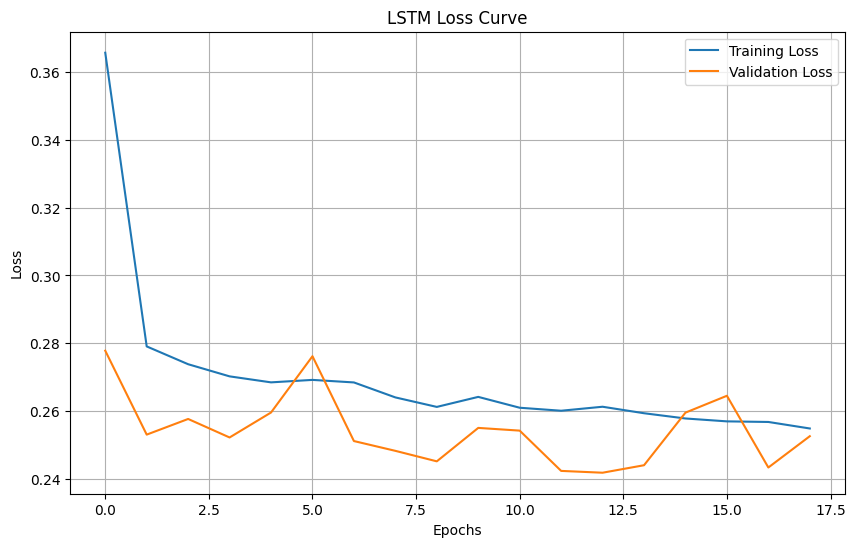

In [102]:
# Assuming `history` is the variable storing the training history from model.fit()
plt.figure(figsize=(10, 6))
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [103]:
# Create results_df before predictions
results_df = pd.DataFrame({
    'indicator': ind_test,
    'activity_score_normalized': [
        data[data['indicator'] == ind]['activity_score_normalized'].iloc[0]
        if ind in data['indicator'].values else 0.5  # Default to 0.5 if missing
        for ind in ind_test
    ]
})

# Predict on test set
y_pred_prob = model.predict(X_test).flatten()

# Adjust threshold based on activity_score
# Map activity_score_normalized from results_df to ind_test
threshold_map = results_df.set_index('indicator')['activity_score_normalized'].to_dict()

# Calculate thresholds directly without handling missing indicators
thresholds = np.array([
    0.35 + 0.15 * threshold_map[ind]
    for ind in ind_test
])

# Ensure lengths match and apply thresholds
if len(y_pred_prob) != len(thresholds):
    raise ValueError("Mismatch between prediction probabilities and thresholds length.")

y_pred = (y_pred_prob > thresholds).astype(int)

# Group by indicator and calculate stats
from collections import defaultdict

indicator_stats = defaultdict(lambda: {'true': [], 'pred': [], 'prob': []})
for i, ind in enumerate(ind_test):
    indicator_stats[ind]['true'].append(y_test[i])
    indicator_stats[ind]['pred'].append(y_pred[i])
    indicator_stats[ind]['prob'].append(y_pred_prob[i])

# Build summary
summary = []
for ind, vals in indicator_stats.items():
    acc = np.mean(np.array(vals['true']) == np.array(vals['pred']))
    avg_prob = np.mean(vals['prob'])
    date = data[data['indicator'] == ind]['date'].values[0] if ind in data['indicator'].values else np.nan
    seen_value = test_data[test_data['indicator'] == ind]['seen'].values
    seen = seen_value[0] if len(seen_value) > 0 else np.nan  # Handle missing 'seen' values
    summary.append({
        'indicator': ind,
        'accuracy': round(acc, 3),
        'avg_predicted_probability': round(avg_prob, 3),
        'samples': len(vals['true']),
        'seen': seen
    })

# Convert summary to DataFrame
results_df = pd.DataFrame(summary).sort_values(by='avg_predicted_probability', ascending=False)

# Display the top 500 results
results_df.head(500)

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


,indicator,accuracy,avg_predicted_probability,samples,seen
199,34.160.111.145,0.720,0.918,25,0
119,162.142.125.247,0.762,0.900,21,0
102,162.142.125.242,0.893,0.897,28,1
161,162.142.125.255,0.842,0.881,19,1
27,185.230.63.171,0.750,0.866,20,1
...,...,...,...,...,...
25,31.31.196.208,1.000,0.007,24,0
98,146.70.57.34,1.000,0.007,22,0
51,international.standardbank.com/,1.000,0.006,30,0
133,149.88.27.231,0.960,0.006,25,0


In [104]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification report
class_report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])
print("\nClassification Report:")
print(class_report)

# AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"\nAUC Score: {auc_score:.4f}")

# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Confusion Matrix:
[[3961   67]
 [ 334  170]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.92      0.98      0.95      4028
     Class 1       0.72      0.34      0.46       504

    accuracy                           0.91      4532
   macro avg       0.82      0.66      0.71      4532
weighted avg       0.90      0.91      0.90      4532


AUC Score: 0.8358

Precision: 0.7173
Recall: 0.3373
F1-Score: 0.4588


In [105]:
# Extract the indicators from both dataframes
results_indicators = set(results_df['indicator'])
test_data_indicators = set(test_data['indicator'])

# Find matching indicators
matching_indicators = results_indicators.intersection(test_data_indicators)

# Find missing indicators in test_data
missing_in_test_data = results_indicators.difference(test_data_indicators)

# Find missing indicators in sorted_results_df
missing_in_sorted_results = test_data_indicators.difference(results_indicators)

# Display the results
print("Matching Indicators:", matching_indicators)
print("Indicators in results_df but missing in test_data:", missing_in_test_data)
print("Indicators in test_data but missing in results_df:", missing_in_sorted_results)

Matching Indicators: {'104.21.48.1', '23.205.105.180', '23.26.221.2', '84.239.31.15', '89.31.143.90', '46.246.8.56', '70.39.120.10', '191.96.36.115', '46.246.8.77', '20.48.204.4', '156.146.63.166', '46.246.8.9', '185.230.63.171', '23.26.221.4', '149.102.250.14', '149.88.27.231', '156.146.63.173', '46.246.8.136', '15.235.218.150', '72.167.241.180', '46.246.8.122', '173.254.104.138', '45.142.193.183', '46.246.8.116', '143.95.44.89', '162.142.125.247', '64.64.112.131', '156.146.63.177', '45.142.193.141', '46.246.8.43', '23.26.221.29', '46.246.8.44', '62.173.38.206', '84.239.47.90', '149.36.49.225', '216.24.216.204', '46.246.8.75', '79.98.104.4', '23.26.221.15', '23.26.221.25', '46.246.8.17', '46.246.8.90', '156.146.63.175', '156.146.63.181', '192.124.249.112', '156.146.63.178', '178.175.129.37', '156.146.63.169', '102.165.16.161', '3.14.182.203', '156.146.63.133', '162.241.216.236', '45.142.193.247', '146.70.204.179', '77.75.73.61', '23.26.221.22', '67.225.140.4', '171.25.193.20', '185.22

In [106]:

# Filter the matching indicators from results_df
matching_indicators_data = results_df[results_df['indicator'].isin(data['indicator'])]

# Get the list of indicators from matching_indicators_data
matching_indicators = matching_indicators_data['indicator'].unique()

# Filter the last 90 days of data for these indicators where seen = 1
ninety_days_ago = datetime.now() - timedelta(days=90)
seen_in_last_90_days = data[
    (data['indicator'].isin(matching_indicators)) & 
    (data['seen'] == 1) & 
    (data['date'] >= ninety_days_ago)
]

# Get the list of indicators that have been seen
seen_indicators = seen_in_last_90_days['indicator'].unique()

# Find indicators that have not been seen in the last 90 days
not_seen_indicators = set(matching_indicators) - set(seen_indicators)

# Display the indicators not seen in the last 90 days
if not_seen_indicators:
    print("The following indicators have NOT been seen in the last 90 days:")
    print(not_seen_indicators)
else:
    print("All matching indicators have been seen in the last 90 days.")

# Exclude not_seen_indicators from the display list
display_indicators = set(matching_indicators) - not_seen_indicators

# Display the results
matching_indicators_data[matching_indicators_data['indicator'].isin(display_indicators)][['indicator', 'avg_predicted_probability']]

The following indicators have NOT been seen in the last 90 days:
{'146.70.204.179', '149.88.27.231', '146.70.57.34', '67.225.140.4', '208.87.233.190', '185.220.101.149', 'international.standardbank.com/', '31.31.196.208'}


,indicator,avg_predicted_probability
199,34.160.111.145,0.918
119,162.142.125.247,0.900
102,162.142.125.242,0.897
161,162.142.125.255,0.881
27,185.230.63.171,0.866
...,...,...
113,5.79.110.170,0.009
20,191.96.36.115,0.008
50,207.244.89.161,0.008
144,20.233.253.125,0.008


In [107]:
# Add a column to indicate whether the prediction was "Right" or "Wrong"
matching_indicators_data.loc[:, 'prediction_status'] = matching_indicators_data.apply(
    lambda row: 'Right' if (row['avg_predicted_probability'] >= 0.5 and row['seen'] == 1) or
                              (row['avg_predicted_probability'] < 0.5 and row['seen'] == 0)
                else 'Wrong',
    axis=1
)

# Identify false negatives: indicators in matching_indicators_data but below the threshold
false_negatives = results_df[
    (results_df['indicator'].isin(matching_indicators_data['indicator'])) & 
    (results_df['avg_predicted_probability'] < 0.5) &  # Below the threshold for being seen
    (results_df['seen'] == 1) &  # Actual value is seen
    (~results_df['indicator'].isin(not_seen_indicators))
].copy()

if not false_negatives.empty:
    false_negatives.loc[:, 'prediction_status'] = 'False Negative'

# Identify false positives: indicators not in matching_indicators_data but meet the threshold
false_positives = results_df[
    (results_df['avg_predicted_probability'] >= 0.5) &  # Above the threshold for being seen
    (results_df['seen'] == 0) &  # Actual value is not seen
    (~results_df['indicator'].isin(not_seen_indicators))
].copy()

if not false_positives.empty:
    false_positives.loc[:, 'prediction_status'] = 'False Positive'

# Combine all results
combined_results = pd.concat([matching_indicators_data, false_negatives, false_positives])

# Resolve duplicate indicators by prioritizing "False Negative" and "False Positive" over "Wrong"
final_results = (
    combined_results.sort_values(by='prediction_status', key=lambda col: col.map({'False Negative': 1, 'False Positive': 2, 'Wrong': 3, 'Right': 4}))
    .drop_duplicates(subset='indicator', keep='first')
)

# Display the final results
final_results[['indicator', 'avg_predicted_probability', 'seen', 'prediction_status']]

,indicator,avg_predicted_probability,seen,prediction_status
15,156.146.63.166,0.114,1,False Negative
104,156.146.63.130,0.095,1,False Negative
38,66.22.212.131,0.025,1,False Negative
26,192.124.249.112,0.028,1,False Negative
141,46.246.8.136,0.030,1,False Negative
...,...,...,...,...
116,104.21.3.76,0.009,0,Right
113,5.79.110.170,0.009,0,Right
51,international.standardbank.com/,0.006,0,Right
98,146.70.57.34,0.007,0,Right


In [108]:
# Calculate total predictions and total right predictions from final_results
total_predictions_final = len(final_results)
total_right_predictions_final = len(final_results[final_results['prediction_status'] == 'Right'])

# Calculate the ratio
right_predictions_ratio_final = total_right_predictions_final / total_predictions_final

# Print the ratio in '199/205' format
print(f"Ratio of right predictions to total predictions (final results): {total_right_predictions_final}/{total_predictions_final}")

# Calculate the accuracy of the ratio
accuracy_final = (total_right_predictions_final / total_predictions_final) * 100

# Print the accuracy
print(f"Accuracy (final results): {accuracy_final:.2f}%")

Ratio of right predictions to total predictions (final results): 177/206
Accuracy (final results): 85.92%


In [109]:
# Extract rows where prediction_status is either "False Negative" or "False Positive"
false_negatives_and_positives = final_results[
    final_results['prediction_status'].isin(['False Negative', 'False Positive'])
].copy()

# Display the extracted rows
false_negatives_and_positives

,indicator,accuracy,avg_predicted_probability,samples,seen,prediction_status
15,156.146.63.166,0.921,0.114,38,1,False Negative
104,156.146.63.130,0.917,0.095,24,1,False Negative
38,66.22.212.131,1.000,0.025,26,1,False Negative
26,192.124.249.112,0.895,0.028,19,1,False Negative
141,46.246.8.136,0.913,0.030,23,1,False Negative
78,185.253.162.21,0.542,0.436,24,1,False Negative
54,156.146.63.167,0.909,0.115,22,1,False Negative
187,www.shorturl.at/,0.750,0.459,24,1,False Negative
60,156.146.63.179,0.947,0.145,19,1,False Negative
193,46.246.8.5,0.958,0.145,24,1,False Negative


In [110]:
correct_seen_predictions = ((final_results['seen'] == 1) & (final_results['prediction_status'] == 'Right'))
correct_seen_predictions

15     False
104    False
38     False
26     False
141    False
       ...  
116    False
113    False
51     False
98     False
157    False
Length: 206, dtype: bool

In [111]:
((final_results['seen'] == 1) & (final_results['prediction_status'] == 'Right')).sum()


np.int64(7)

In [112]:
# Calculate the number of correct "seen" predictions
correct_seen_predictions = ((final_results['seen'] == 1) & (final_results['prediction_status'] == 'Right')).sum()

# Calculate the total actual "seen" values
total_actual_seen = (final_results['seen'] == 1).sum()

Ratio = correct_seen_predictions / total_actual_seen * 100
# Print the results
print(f"Number of correct 'seen' predictions: {correct_seen_predictions}")
print(f"Total actual 'seen': {total_actual_seen}")
print(f"Ratio : {Ratio:.2f}")

Number of correct 'seen' predictions: 7
Total actual 'seen': 34
Ratio : 20.59


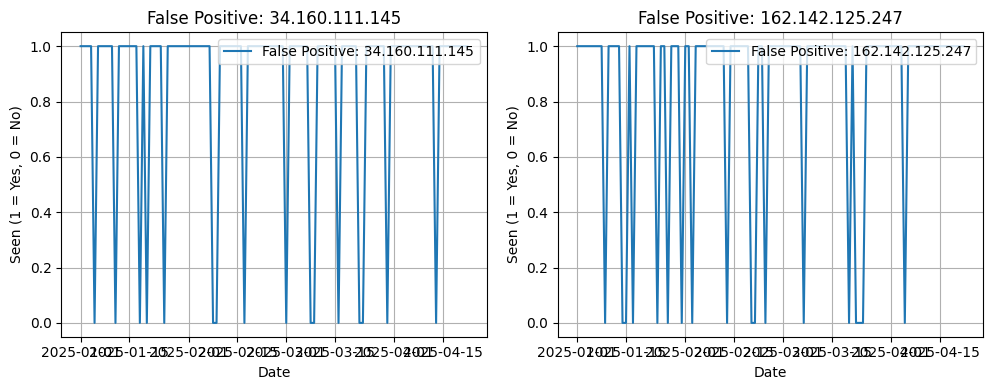

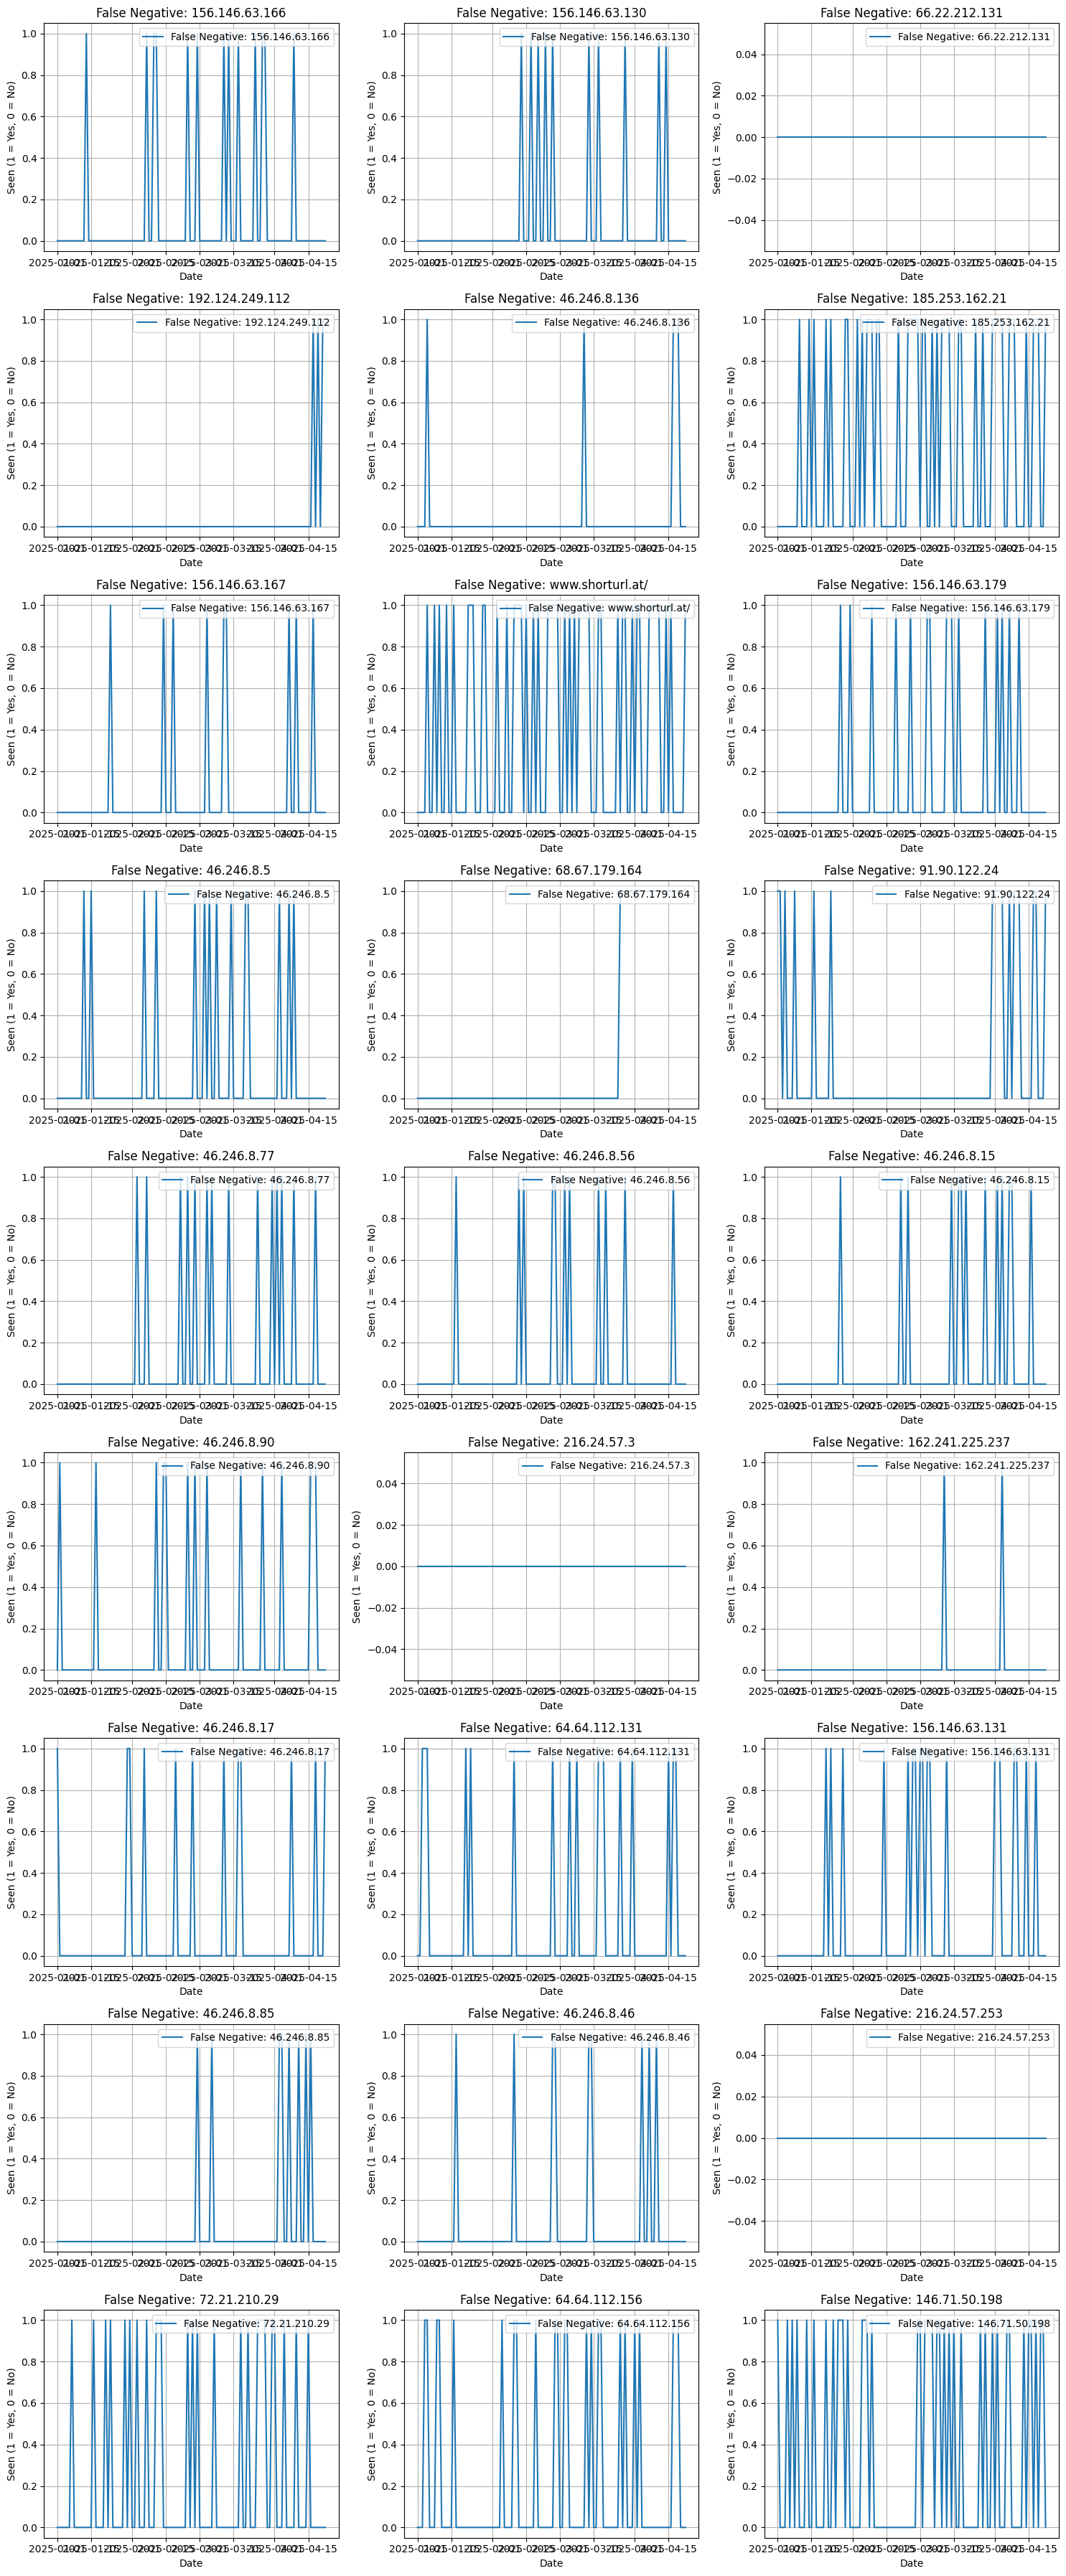

In [113]:
import matplotlib.pyplot as plt
import math

# Separate false positives and false negatives
false_positives = false_negatives_and_positives[
    false_negatives_and_positives['prediction_status'] == 'False Positive'
]

false_negatives = false_negatives_and_positives[
    false_negatives_and_positives['prediction_status'] == 'False Negative'
]

# Merge false positives and false negatives with modelData to get historical activity
false_positive_activity = modelData[modelData['indicator'].isin(false_positives['indicator'])]
false_negative_activity = modelData[modelData['indicator'].isin(false_negatives['indicator'])]

# Function to plot indicators in a grid
def plot_indicators_in_grid(activity_data, indicators, title_prefix):
    num_indicators = len(indicators)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_indicators / cols)  # Calculate rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, indicator in enumerate(indicators):
        ax = axes[i]
        indicator_data = activity_data[activity_data['indicator'] == indicator]
        ax.plot(indicator_data['date'], indicator_data['seen'], label=f'{title_prefix}: {indicator}')
        ax.set_title(f'{title_prefix}: {indicator}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Seen (1 = Yes, 0 = No)')
        ax.legend(loc='upper right')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(indicators), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Plot false positives in a grid
plot_indicators_in_grid(false_positive_activity, false_positives['indicator'].unique(), 'False Positive')

# Plot false negatives in a grid
plot_indicators_in_grid(false_negative_activity, false_negatives['indicator'].unique(), 'False Negative')

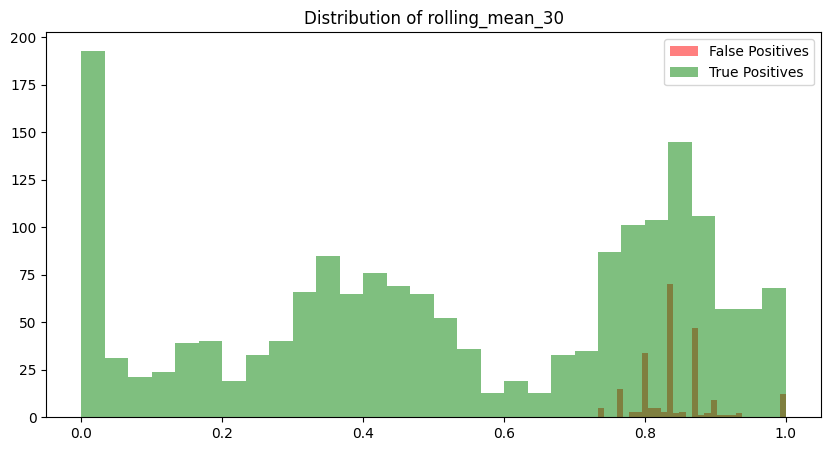

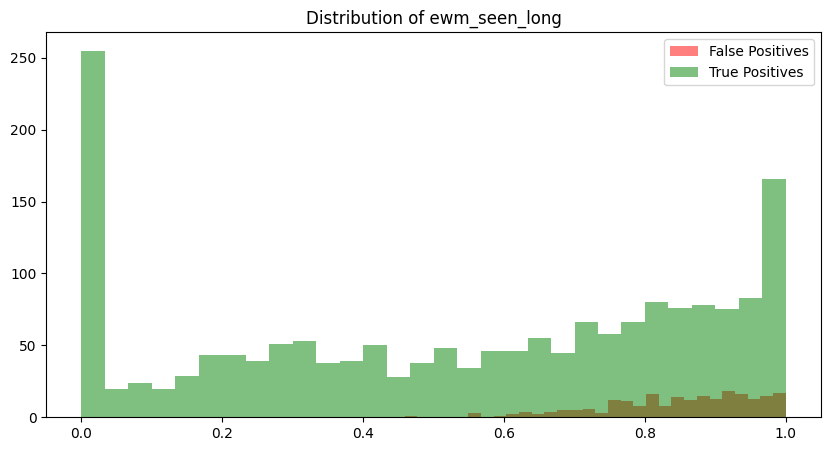

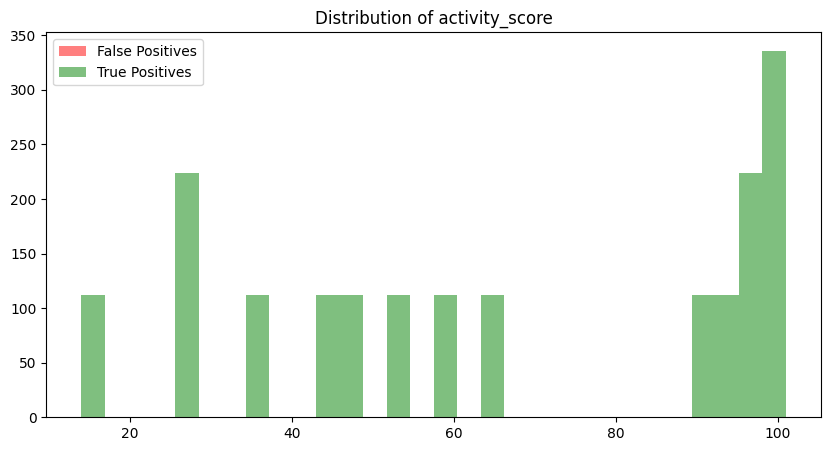

In [114]:
false_positive_data = modelData[modelData['indicator'].isin(false_positives['indicator'])]
# Get the indices of true positives
true_positive_indices = np.where((y_pred == 1) & (y_test == 1))[0]

# Filter modelData for true positives using the corresponding indicators
true_positive_indicators = ind_test[true_positive_indices]
true_positive_data = modelData[modelData['indicator'].isin(true_positive_indicators)]

# Compare feature distributions
for feature in ['rolling_mean_30', 'ewm_seen_long', 'activity_score']:
    plt.figure(figsize=(10, 5))
    plt.hist(false_positive_data[feature], bins=30, alpha=0.5, label='False Positives', color='red')
    plt.hist(true_positive_data[feature], bins=30, alpha=0.5, label='True Positives', color='green')
    plt.title(f'Distribution of {feature}')
    plt.legend()
    plt.show()

In [115]:
modelData[modelData['indicator'] == '68.67.179.164']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_30,ewm_seen_long,activity_score,activity_score_normalized,activity_tier
20496,2025-01-01,68.67.179.164,2,False,0,0,0.0,0.0,0.0,0.000000,0.000000,35,0.34,2
20497,2025-01-02,68.67.179.164,3,False,0,0,0.0,0.0,0.0,0.000000,0.000000,35,0.34,2
20498,2025-01-03,68.67.179.164,4,False,0,0,0.0,0.0,0.0,0.000000,0.000000,35,0.34,2
20499,2025-01-04,68.67.179.164,5,True,0,0,0.0,0.0,0.0,0.000000,0.000000,35,0.34,2
20500,2025-01-05,68.67.179.164,6,True,0,0,0.0,0.0,0.0,0.000000,0.000000,35,0.34,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20603,2025-04-18,68.67.179.164,4,False,1,1,1.0,3.0,1.0,0.800000,0.991902,35,0.34,2
20604,2025-04-19,68.67.179.164,5,True,1,1,1.0,3.0,1.0,0.833333,0.993374,35,0.34,2
20605,2025-04-20,68.67.179.164,6,True,1,1,1.0,3.0,1.0,0.866667,0.994579,35,0.34,2
20606,2025-04-21,68.67.179.164,0,False,1,1,1.0,3.0,1.0,0.900000,0.995564,35,0.34,2


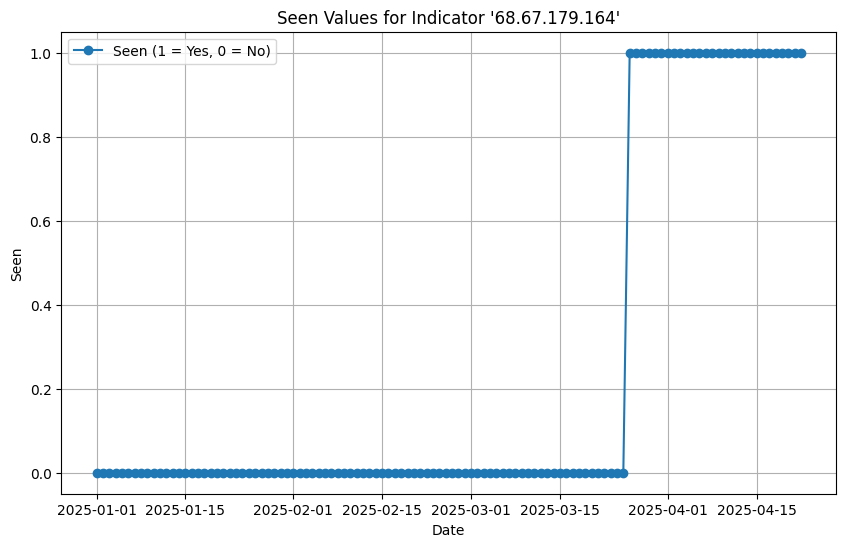

In [116]:
# Filter data for the specified indicator
indicator_data = modelData[modelData['indicator'] == '68.67.179.164']

# Plot the 'seen' values over time
plt.figure(figsize=(10, 6))
plt.plot(indicator_data['date'], indicator_data['seen'], marker='o', label='Seen (1 = Yes, 0 = No)')
plt.title("Seen Values for Indicator '68.67.179.164'")
plt.xlabel("Date")
plt.ylabel("Seen")
plt.legend()
plt.grid(True)
plt.show()

In [117]:
days_since_last_seen = modelData['days_since_last_seen']

days_since_last_seen = test_data.groupby('indicator').agg({
    'days_since_last_seen': ['mean', 'max']
}).reset_index()

# Rename columns for clarity
days_since_last_seen.columns = ['indicator', 'mean_days_since_last_seen', 'max_days_since_last_seen']

days_since_last_seen

,indicator,mean_days_since_last_seen,max_days_since_last_seen
0,102.129.153.158,31.0,31
1,102.129.153.43,3.0,3
2,102.129.153.71,4.0,4
3,102.165.16.161,18.0,18
4,104.160.6.2,5.0,5
...,...,...,...
201,international.standardbank.com/,97.0,97
202,pub.marq.com/,18.0,18
203,realinvestmentadvice.com/,3.0,3
204,www.emergencylighting.com/,75.0,75


In [118]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the top features
print("Top Features:")
print(feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.tight_layout()
plt.show()

ValueError: Found array with dim 3. RandomForestClassifier expected <= 2.